# Email Spam Detection using Machine Learning

## Objective
The objective of this project is to classify SMS messages as Spam or Ham using Natural Language Processing (NLP) and Machine Learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [3]:
df.shape

(5572, 5)

In [4]:
df = df[['v1', 'v2']]
df.columns = ['Label', 'Message']

In [5]:
df.isnull().sum()

Label      0
Message    0
dtype: int64

In [6]:
df.duplicated().sum()

403

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['Label'].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

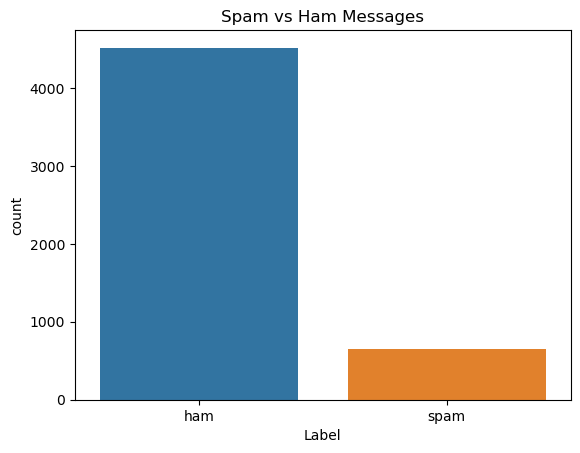

In [21]:
sns.countplot(x='Label', data=df)
plt.title("Spam vs Ham Messages")
plt.show()

The dataset contains two classes: Ham (non-spam) and Spam. Duplicate records were removed before training the model.

In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shrey\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [10]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    return " ".join(words)

df['Message'] = df['Message'].apply(preprocess)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['Message'])

y = df['Label']

TF-IDF converts text messages into numerical features by assigning higher importance to words that are frequent in a message but less common across all messages.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, pos_label='spam'))
    print("Recall   :", recall_score(y_true, y_pred, pos_label='spam'))
    print("F1 Score :", f1_score(y_true, y_pred, pos_label='spam'))

evaluate(y_test, nb_pred, "Multinomial Naive Bayes")
evaluate(y_test, lr_pred, "Logistic Regression")


Multinomial Naive Bayes
Accuracy : 0.9671179883945842
Precision: 0.9911504424778761
Recall   : 0.7724137931034483
F1 Score : 0.8682170542635659

Logistic Regression
Accuracy : 0.9555125725338491
Precision: 0.9459459459459459
Recall   : 0.7241379310344828
F1 Score : 0.8203125


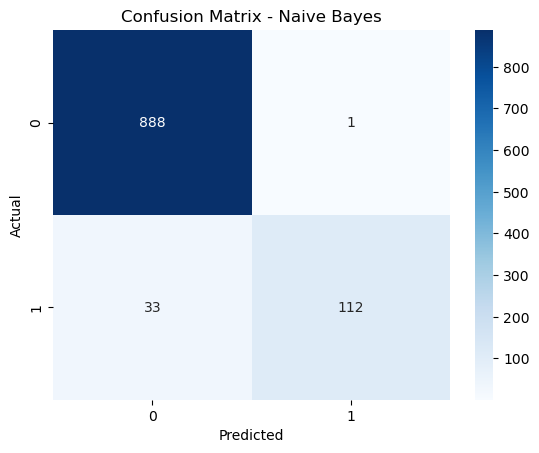

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

## Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|---------:|----------:|-------:|---------:|
| Multinomial Naive Bayes | 96.71% | 99.12% | 77.24% | 86.82% |
| Logistic Regression | 95.55% | 94.59% | 72.41% | 82.03% |

# Conclusion

- The dataset was cleaned and preprocessed successfully.
- Text messages were converted into numerical features using TF-IDF Vectorization.
- Two classification models, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated.
- **Multinomial Naive Bayes achieved the best performance with an accuracy of 96.71% and an F1-score of 86.82%, making it the preferred model for spam detection on this dataset.**